- Zoneamento(bhmap)

O novo Plano Diretor de Belo Horizonte, lei 11.181/19, entrou em vigor na quarta-feira, dia 5 (de fevereiro)
https://prefeitura.pbh.gov.br/politica-urbana/regulacao-urbana/informes-tecnicos/plano-diretor-de-belo-horizonte-regulamentado

- Valor do solo (http://www.rmbh.org.br/central-cartog.php?formato=shp)

# Preliminaries

In [20]:
# Standard library
import os
import pathlib

# Third-party libraries
import geobr
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tobler.area_weighted import area_interpolate
from tobler.util import h3fy

%matplotlib inline
%config InlineBackend.figure_format='retina'

## Parent Folders

These should of course be adjusted to reflect the appropriate locations in your disk or wherever

In [21]:
out_folder = os.environ.get('OUT_FOLDER')
out_folder = pathlib.Path(out_folder)
out_folder = out_folder / 'A'

db_folder = os.environ.get('DB_FOLDER')
db_folder = pathlib.Path(db_folder) / 'beaga'

In [22]:
bh = geobr.read_census_tract(3106200, simplified=False, year=2022).to_crs(31983)
bh = (
    bh
    .reindex(columns=['code_tract', 'geometry'])
    .rename(columns={'code_tract': 'id_setor_censitario'})
    .astype({'id_setor_censitario': np.int64})
    .astype({'id_setor_censitario': str})
    .set_index('id_setor_censitario')
    )

In [23]:
inpath = db_folder / 'agregado_setores_faces_2022.csv'
surr = pd.read_csv(inpath, sep=';')

d = {
    'COD_SETOR_M22FINAL': 'id_setor_censitario',
    'V05400': 'faces',
    'V05406': 'vias_pacimentadas',
    'V05409': 'bueiros',
    'V05412': 'iluminacao',
    'V05418': 'ciclovias',
    'V05421': 'calcadas',
    'V05424': 'obstaculo_calcada',
    'V05427': 'rampa_cadeirante',
    'V05430': 'sem_arvores',
}
surr = surr.rename(columns=d).reindex(columns=d.values())
surr = surr.astype({'id_setor_censitario': 'str'}).set_index('id_setor_censitario')
surr = surr.loc[surr.index.isin(bh.index)]
surr = surr.div(surr.faces, axis='index').fillna(0)
surr['com_arvores'] = 1 - surr.sem_arvores


In [24]:
surr.describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99])

,faces,vias_pacimentadas,bueiros,iluminacao,ciclovias,calcadas,obstaculo_calcada,rampa_cadeirante,sem_arvores,com_arvores
count,5149.0,5149.000000,5149.000000,5149.000000,5149.000000,5149.000000,5149.000000,5149.000000,5149.000000,5149.000000
mean,1.0,0.971606,0.559428,0.972190,0.020712,0.888957,0.615555,0.293450,0.327992,0.672008
std,0.0,0.116882,0.316644,0.110451,0.079703,0.230158,0.324971,0.334151,0.297381,0.297381
min,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1%,1.0,0.306000,0.000000,0.333333,0.000000,0.032222,0.000000,0.000000,0.000000,0.000000
10%,1.0,0.950000,0.095238,0.937500,0.000000,0.529085,0.067879,0.000000,0.000000,0.181818
25%,1.0,1.000000,0.307692,1.000000,0.000000,0.909091,0.368421,0.000000,0.062500,0.500000
50%,1.0,1.000000,0.571429,1.000000,0.000000,1.000000,0.692308,0.166667,0.250000,0.750000
75%,1.0,1.000000,0.833333,1.000000,0.000000,1.000000,0.896552,0.500000,0.500000,0.937500
90%,1.0,1.000000,1.000000,1.000000,0.058824,1.000000,1.000000,0.888889,0.818182,1.000000


In [25]:
surr = surr.reindex(columns=[
    'bueiros',
    'obstaculo_calcada',
    'rampa_cadeirante',
    'com_arvores'
    ])

In [26]:
surr = bh.merge(surr, right_index=True, left_on='id_setor_censitario')

In [27]:
surr.sample(3)

,geometry,bueiros,obstaculo_calcada,rampa_cadeirante,com_arvores
id_setor_censitario,,,,,
310620005620554,"MULTIPOLYGON (((610496.11 7794251.478, 610508....",1.000000,0.125000,0.750000,1.000000
310620005680150,"MULTIPOLYGON (((605437.148 7802084.755, 605425...",0.954545,0.818182,0.954545,0.954545
310620005650595,"MULTIPOLYGON (((605644.808 7796487.534, 605501...",0.444444,0.444444,0.444444,0.888889


In [28]:
outpath = out_folder / 'entorno.gpkg'
surr.to_file(outpath)

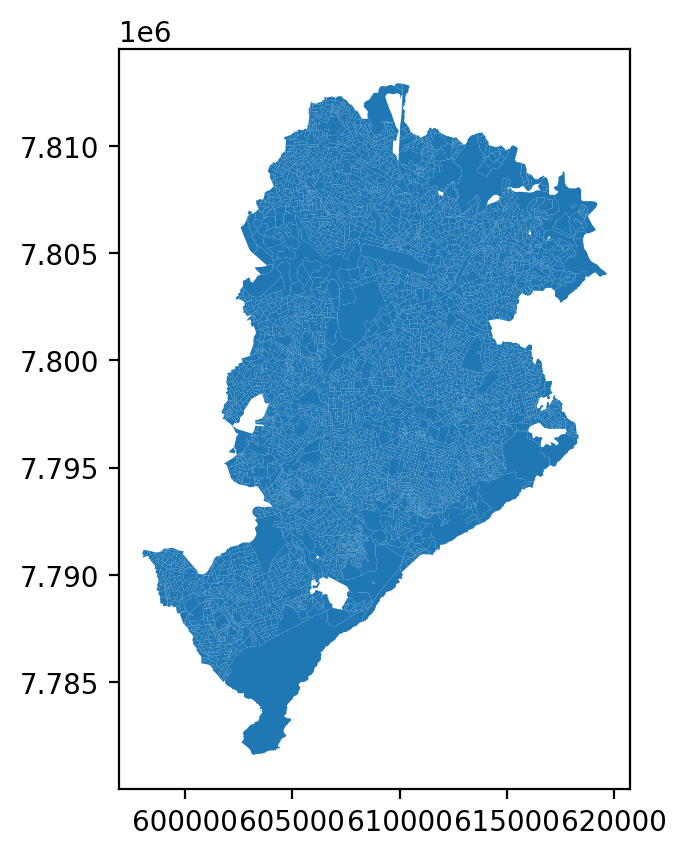

In [29]:
surr.plot()
plt.show()